redukce dimenzionality a binární klasifikace

 
  * V rámci tohoto úkolu se musíte vypořádat s vysokou dimenzí problému a poté úspěšně aplikovat vhodný klasfikační model.

## Zdroj dat

 * Zdrojem dat jsou soubory `train.csv` a `evaluate.csv`.
 * Jedná se o obrázky 28x28 pixelů ve stupních šedi, které byly získány z [Fashion Mnist datasetu](https://www.kaggle.com/datasets/zalando-research/fashionmnist).
 * Soubor `train.csv` obsahuje trénovací data.
 * Cílová (vysvětlovaná) proměnná se jmenuje **label**.
 * Soubor `evaluate.csv` obsahuje testovací data bez hodnot skutečných labelů.

## Pokyny k vypracování

  * V notebooku načtěte data ze souboru `train.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování, porovnávání modelů a následnou predikci výkonnosti finálního modelu.
  * Proveďte základní průzkum dat a svá pozorování diskutujte. Některé obrázky také zobrazte.
  * Postupně aplikujte modely **SVM**, **naivní Bayesův klasifikátor** a **LDA**, přičemž pro každý z nich:
      * Okomentujte vhodnost daného modelu pro daný typ úlohy.
      * Vyberte si hlavní hyperparametry k ladění (pokud model má hyperparametry) a najděte jejich nejlepší hodnoty.
      * Experimentujte se standardizací/normalizací dat.
      * U SVM vyzkoušejte alespoň dvě různé jádrové funkce.
      * Získané výsledky vždy řádně okomentujte.


  * Postupně aplikujte metody redukce dimenzionality PCA a LLE, přičemž pro každou z nich: 
      * Zopakujte předchozí kroky a pokuste modely vylepšit
      * Zkoumejte jaká dimenze je z hlediska výkonnosti finálního modelu nejlepší.
      * Získané výsledky vždy řádně okomentujte.
    
  * Ze všech zkoušených možností vyberte finální model a odhadněte, jakou přesnost můžete očekávat na nových datech, která jste doposud neměli k dispozici.
  
  * Nakonec načtěte vyhodnocovací data ze souboru`evaluate.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data (vysvětlovaná proměnná v nich již není). Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **label** a identifikátory do sloupce **ID**. Tento soubor též odevzdejte (uložte do projektu vedle notebooku).
   
   * Ukázka prvních řádků souboru `results.csv`:
  
```
ID,label
0,0
1,1
...
```


In [1]:
import math
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from random import randrange
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding

import warnings

In [2]:
df = pd.read_csv("train.csv")

In [3]:
XdataIn = df.drop("label", axis = 1)
Ydata = df["label"]
rd_seed = 333
Xtrain, Xtest, Ytrain, Ytest = train_test_split(XdataIn, Ydata, test_size=0.4, random_state=rd_seed) 
Xval, Xtest, Yval, Ytest = train_test_split(Xtest, Ytest, test_size=0.5, random_state=rd_seed)

v datasetu je 2400 záznamů a obrázky mají 28*28 pixelů

In [4]:
df.shape

(2400, 785)

In [5]:
print(df["pixel722"].unique())
print(df["pixel1"].unique())
print(df["pixel500"].unique())
print(df["pixel784"].unique())

[  0   1   8  43   5   4 138  34 100 245 212  11 167 191 196   2   3 153
 139  28  76 120   9  25  13  15  24 213 136 225 200   6 239 103  97  73
 119 207 195  74 177  66  80  88 220 122  84 128 188 107 104 181  61  44
 156  81 227 117  83  92 221  79 132 130  99   7  63  59  17 163 106 135
  98 124 179 161  41  64  36 172  12  57  40  14 253 154  27  71  60  86
 164 141 165  49  53 214 105  32 222 182 116  45 255  33 155  23 149 113
 112 210 147 159 151 174 241 217 162 180 218 166  56  96  35 110  72 247
 160 109  20 137 145  31  22 187 189 133  87 203  62 211  48 108 144 126
  68  38  19 232 152 206  67 111  55  47 148 114 243 185 229]
[0]
[  0 112 181  61 200   5 118  45 180 183 199 133  62   1   8 144  89   2
  34  70 190 132 117  72 225  63  32  37 172  92 239 122 148  66  13 102
 255  51 178 121  40 154  14 238 139 230  76 222 142  16  99  26  69 100
 108  88 140 119 150  87  86  33 114  79 120  22   3   7 138 189   6 110]
[0]


In [6]:
def show_pic(index):
    image_pixels = df.iloc[index, 1:].values.astype(np.uint8)
    print(df.iloc[index, 0])
    image = image_pixels.reshape((28, 28))

    plt.imshow(image, cmap='gray')
    plt.title('Fashion MNIST Image')
    plt.axis('off')
    plt.show()

0


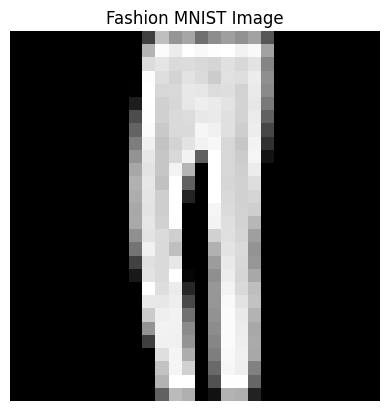

1


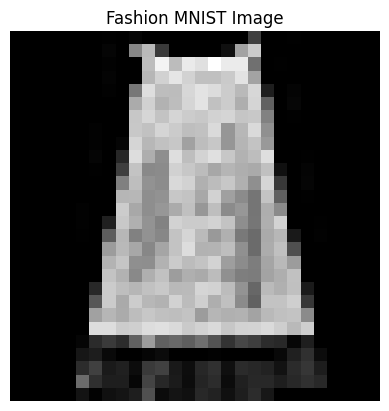

1


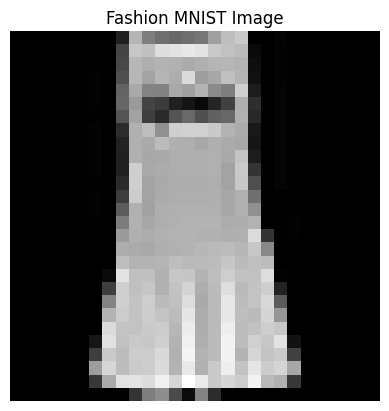

0


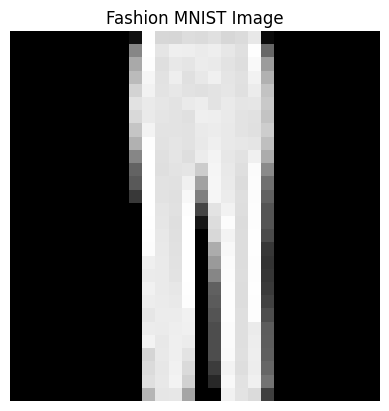

1


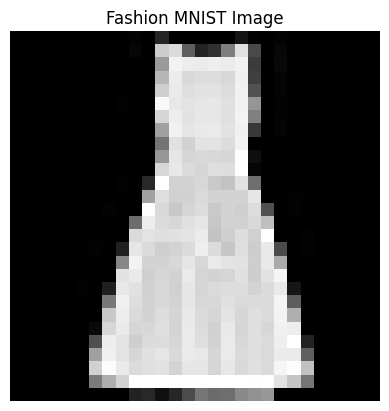

0


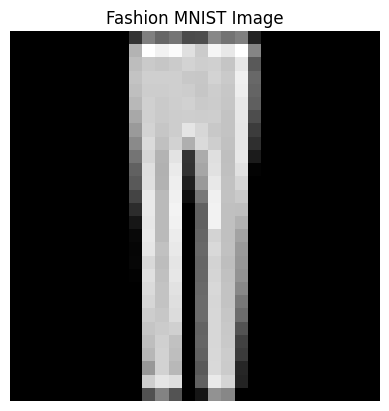

In [7]:
show_pic(1000)
show_pic(10)
show_pic(52)
show_pic(79)
show_pic(842)
show_pic(115)

In [8]:
df["label"].unique()

array([1, 0], dtype=int64)

obrázky jsou jen T-shirt/top a Trouser

### STANDARDIZACE

V datasetu budu experimentovat se standardizací i normalizací

In [9]:
scaler_std = StandardScaler()
scaler_std.fit(Xtrain)

# X_train_std = scaler_std.transform(Xtrain)
# X_val_std = scaler_std.transform(Xval)
# X_test_std = scaler_std.transform(Xtest)

StandardScaler()

### NORMALIZACE

In [10]:
scaler_mm = MinMaxScaler()
scaler_mm.fit(Xtrain)

# X_train_minmax = scaler_mm.transform(Xtrain)
# X_val_minmax = scaler_mm.transform(Xval)
# X_test_minmax = scaler_mm.transform(Xtest)

MinMaxScaler()

### SVM

SVM se používají na vyhodnocování textů a obrázků. SVM (narozdíl od Bayese) nevadí závislá data. Není náchylný na přeučení a není náchylný na vysoké dimenze (v nich je větší šance že najde separující nadrovinu). Nevýhoda je ve výpočetní náročnosti.

In [11]:
def best_svm_model(data, results, val_data, val_results):
    best_kernel = 1
    best_score = 0
    best_regularization = 1
    best_degree = 1
    
    for regularization in range(1, 1000, 150):
#         print("lin", regularization)
        svm_model_lin = SVC(C = regularization, kernel = 'linear', max_iter = 1000000)    
        svm_model_lin.fit(data, results)
        score = svm_model_lin.score(val_data, val_results)
        if score > best_score:
            best_score = score
            best_kernel = 1
            best_regularization = regularization
            
    for regularization in range(1, 1000, 150):
        for degree in range(2, 4):
#             print("pol", regularization)
            svm_model_pol = SVC(C = regularization, kernel = 'poly', degree=degree, max_iter = 1000000)    
            svm_model_pol.fit(data, results)
            score = svm_model_pol.score(val_data, val_results)
            if score > best_score:
                best_score = score
                best_kernel = 2
                best_regularization = regularization
                best_degree = degree

    return [best_kernel, best_score, best_regularization, best_degree]

In [12]:
def getSVM(Xdata, Ydata, Xref, Yref):
    #     0 without, 1 std, 2 mm
    std_data = scaler_std.transform(Xdata)
    std_ref = scaler_std.transform(Xref)
    mm_data = scaler_mm.transform(Xdata)
    mm_ref = scaler_mm.transform(Xref)  
    
#     print(Xdata.shape)
#     print(mm_data.shape)
#     print(std_data.shape)
    
#     print("default")
    data_type = 0
    params = best_svm_model(Xdata, Ydata, Xref, Yref)
    result = [0, params[1]]
    
#     print("std")
    tmp = best_svm_model(std_data, Ydata, std_ref, Yref)
    result = result + [1, tmp[1]]

#     print("minmax")
    tmp = best_svm_model(mm_data, Ydata, mm_ref, Yref)
    result = result + [2, tmp[1]]

    out = [result[i:i+2] for i in range(0, len(result), 2)]
    return out


### NAIVE BAYES

Největší problém s Bayesem je, že předpokládá nezávislost dat, která zde není splněna, protože když máme pixel s vysokou hodnotou (velmi jasná bílá barva), zvyšuje se pravděpodobnost, že sousední pixel bude také bílý. 

BernoullihoNB shlukne všechny příznaky vetší nebo rovné 1 na 1 a zbytek nechá na 0.

In [13]:
def get_NB_error(data, results, val_data, val_results):
    bayes = BernoulliNB();
    bayes.fit(data, results)
    score = bayes.score(val_data, val_results)
    return score

In [14]:
def getBayes(Xdata, Ydata, Xref, Yref):
#     0 without, 1 std, 2 mm
    std_data = scaler_std.transform(Xdata)
    std_ref = scaler_std.transform(Xref)
    mm_data = scaler_mm.transform(Xdata)
    mm_ref = scaler_mm.transform(Xref)    

    data_type = 0
    score = get_NB_error(Xdata, Ydata, Xref, Yref)
    result = [0, score]
    
    tmp = get_NB_error(std_data, Ydata, std_ref, Yref)
    result = result + [1, tmp]

    tmp = get_NB_error(mm_data, Ydata, mm_ref, Yref)
    result = result + [2, tmp]
    
    out = [result[i:i+2] for i in range(0, len(result), 2)]

    return out

### LDA

Největší problém s LDA je, že předpokládá normalitu a stejnou kovarianci, která zde nejde zaručit.

In [15]:
def get_lda_error(data, result, data_val, result_val):
    lda = LinearDiscriminantAnalysis()
    lda.fit(data, result)
    score = lda.score(data_val, result_val)
    return score

In [16]:
def getLDA(Xdata, Ydata, Xref, Yref):

    std_data = scaler_std.transform(Xdata)
    std_ref = scaler_std.transform(Xref)
    mm_data = scaler_mm.transform(Xdata)
    mm_ref = scaler_mm.transform(Xref)
    
    
    data_type = 0
    score = get_lda_error(Xdata, Ydata, Xref, Yref)
    result = [0, score]
    
    tmp = get_lda_error(std_data, Ydata, std_ref, Yref)
    result = result + [1, tmp]

    tmp = get_lda_error(mm_data, Ydata, mm_ref, Yref)
    result = result + [2, tmp]
    
    out = [result[i:i+2] for i in range(0, len(result), 2)]

    return out

In [17]:
SVM = getSVM(Xtrain, Ytrain, Xval, Yval)
SVM

[[0, 0.9833333333333333], [1, 0.9770833333333333], [2, 0.9854166666666667]]

In [18]:
BA = getBayes(Xtrain, Ytrain, Xval, Yval)
BA

# gaussian bayes - 63 - nebudu ani dal zkouset

[[0, 0.9333333333333333], [1, 0.9291666666666667], [2, 0.9333333333333333]]

In [19]:
LDA = getLDA(Xtrain, Ytrain, Xval, Yval)
LDA

[[0, 0.9229166666666667], [1, 0.9229166666666667], [2, 0.9229166666666667]]

Bez redukce dimenzionality vypadá, že normalizace a standardizace nemá skoro žádný efekt. Zároveň na těchto datech nejlépe skóruje SVM model.

### PCA

785 puvodnich komponent

PCA vybírá komponenty ve směru největšího rozptylu, takže je velká šance, že zredukuje komponenty s menším rozptylem (nesou méně signifikantní informaci) a tím může ingorovat šum.

In [20]:
bestLDA = [0,0,0]

for comp in range (300, 785, 5):
    if comp % 50 == 0:
        print(comp)
    pca = PCA(n_components=comp)
    pca_data = pca.fit_transform(Xtrain)
    pca_ref = pca.transform(Xval)

    scaler_std = StandardScaler()
    scaler_std.fit(pca_data)

    scaler_mm = MinMaxScaler()
    scaler_mm.fit(pca_data)

    LDA = getLDA(pca_data, Ytrain, pca_ref, Yval)
#     print(LDA)
    
    if LDA[0][1] > bestLDA [1]:
        bestLDA = [0,BA[0][1],comp]
        
    if LDA[1][1] > bestLDA [1]:
        bestLDA = [1,BA[1][1],comp]   
        
    if LDA[2][1] > bestLDA[1]:
        bestLDA = [2,BA[2][1],comp] 
    
    

300
350
400
450
500
550
600
650
700
750


In [21]:
bestBA = [0,0,0]

for comp in range (10, 780,10):
    if comp % 50 == 0:
        print(comp)
    pca = PCA(n_components=comp)
    pca_data = pca.fit_transform(Xtrain)
    pca_ref = pca.transform(Xval)

    scaler_std = StandardScaler()
    scaler_std.fit(pca_data)

    scaler_mm = MinMaxScaler()
    scaler_mm.fit(pca_data)

    BA = getBayes(pca_data, Ytrain, pca_ref, Yval)
#     print(BA)
    
    if BA[0][1] > bestBA[1]:
        bestBA = [0,BA[0][1],comp]
        
    if BA[1][1] > bestBA[1]:
        bestBA = [1,BA[1][1],comp]   
        
    if BA[2][1] > bestBA[1]:
        bestBA = [2,BA[2][1],comp] 

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750


Časově náročné - pro demonstraci ukazuji jen okolo hodnoty, která mi vyšla nejlépe

In [22]:
bestSVM = [0,0,0]

for comp in range (100, 150, 2):
    if comp % 10 == 0:
        print(comp)
    pca = PCA(n_components=comp)
    pca_data = pca.fit_transform(Xtrain)
    pca_ref = pca.transform(Xval)

    scaler_std = StandardScaler()
    scaler_std.fit(pca_data)

    scaler_mm = MinMaxScaler()
    scaler_mm.fit(pca_data)

    SVM = getSVM(pca_data, Ytrain, pca_ref, Yval)
#     print(BA)
    
    if SVM[0][1] > bestSVM[1]:
        bestSVM = [0, SVM[0][1], comp]
        
    if SVM[1][1] > bestSVM[1]:
        bestSVM = [1, SVM[1][1], comp]   
        
    if SVM[2][1] > bestSVM[1]:
        bestSVM = [2, SVM[2][1], comp] 

100
110
120
130
140


In [23]:
print(bestBA)
print(bestLDA)
print(bestSVM)

[0, 0.9104166666666667, 140]
[2, 0.9333333333333333, 565]
[1, 0.9875, 118]


Bayes s trochu zhoršil s redukcí, LDA se trochu zlepšilo, ale stále zůstává nejhorším modelem a SVM se také trochu zlepšilo.

### LLE 

Může být výhodnější pro MNIST, protože je schopen zachovat i nelineární závislosti (narozdíl od PCA)

In [24]:
bestLDA = [0, 0, 0, 0]
    
for comp in range (400, 780, 5):
    if comp % 30 == 0:
        print(comp)
    
    for neigh in range (2, 10, 2):
        
        lle = LocallyLinearEmbedding(n_components=comp, n_neighbors=neigh)
        lle_data = lle.fit_transform(Xtrain)
        lle_ref = lle.transform(Xval)

        scaler_std = StandardScaler()
        scaler_std.fit(lle_data)

        scaler_mm = MinMaxScaler()
        scaler_mm.fit(lle_data)

        LDA = getLDA(lle_data, Ytrain, lle_ref, Yval)
    #     print(LDA)

        if LDA[0][1] > bestLDA [1]:
            bestLDA = [0, LDA[0][1], comp, neigh]

        if LDA[1][1] > bestLDA [1]:
            bestLDA = [1, LDA[1][1], comp, neigh]

        if LDA[2][1] > bestLDA[1]:
            bestLDA = [2, LDA[2][1], comp, neigh]


    

420
450
480
510
540
570
600
630
660
690
720
750


In [25]:
bestBA = [0,0,0,0]
    
for comp in range (1, 180, 3):
    if comp % 10 == 0:
        print(comp)
    for neigh in range (1, 10, 2):

        lle = LocallyLinearEmbedding(n_components=comp, n_neighbors=5)
        lle_data = lle.fit_transform(Xtrain)
        lle_ref = lle.transform(Xval)

        scaler_std = StandardScaler()
        scaler_std.fit(lle_data)

        scaler_mm = MinMaxScaler()
        scaler_mm.fit(lle_data)

        BA = getBayes(lle_data, Ytrain, lle_ref, Yval)
    #     print(BA)

        if BA[0][1] > bestBA[1]:
            bestBA = [0,BA[0][1],comp, neigh]

        if BA[1][1] > bestBA[1]:
            bestBA = [1,BA[1][1],comp, neigh]  

        if BA[2][1] > bestBA[1]:
            bestBA = [2,BA[2][1],comp, neigh]


10
40
70
100
130
160


In [26]:
bestSVM = [0,0,0,0]
    
for comp in range (1, 180, 3):
    if comp % 10 == 0:
        print(comp)
    for neigh in range (1, 10, 2):
        lle = LocallyLinearEmbedding(n_components=comp, n_neighbors=5)
        lle_data = lle.fit_transform(Xtrain)
        lle_ref = lle.transform(Xval)

        scaler_std = StandardScaler()
        scaler_std.fit(lle_data)

        scaler_mm = MinMaxScaler()
        scaler_mm.fit(lle_data)

        SVM = getBayes(lle_data, Ytrain, lle_ref, Yval)
    #     print(BA)

        if SVM[0][1] > bestSVM[1]:
            bestSVM = [0,SVM[0][1],comp, neigh]

        if SVM[1][1] > bestSVM[1]:
            bestSVM = [1,SVM[1][1],comp, neigh]

        if SVM[2][1] > bestSVM[1]:
            bestSVM = [2,SVM[2][1],comp, neigh]

10
40
70
100
130
160


In [27]:
print(bestLDA)
print(bestBA)
print(bestSVM)

[0, 0.9833333333333333, 410, 8]
[0, 0.96875, 1, 1]
[0, 0.96875, 1, 1]


Pro LDA model funguje LLE redukce dobře. Pro ostatní vychází, že dokonce stačí jenom jedna dimenze na určení obrázku.

### Nejlepší model

SVM, 119 PCA, std data

In [38]:
pca = PCA(n_components=119)

pca_data = pca.fit_transform(Xtrain)
pca_ref = pca.transform(Xval)

scaler_std = StandardScaler()
scaler_std.fit(pca_data)

std_data = scaler_std.transform(pca_data)
std_ref = scaler_std.transform(pca_ref)


result = best_svm_model(std_data, Ytrain, std_ref, Yval)

In [39]:
result
return [best_kernel, best_score, best_regularization, best_degree]


[2, 0.9854166666666667, 151, 2]

In [42]:
best_model = SVC(C = 151, kernel = 'poly', max_iter = 1000000, degree=2)    
best_model.fit(std_data, Ytrain)



SVC(C=151, degree=2, kernel='poly', max_iter=1000000)

In [49]:
pca_test = pca.transform(Xtest)
std_pca_test = scaler_std.transform(pca_test)


In [50]:
best_model.score(std_pca_test, Ytest)

0.9625

### Výsledný dataset

In [122]:
evaluate = pd.read_csv("evaluate.csv")
result = evaluate[["ID"]]
evaluate = evaluate.drop("ID", axis=1)

In [123]:
evaluate.shape

(9600, 784)

In [124]:
pca_data = pca.transform(evaluate)
std_pca_data = scaler_std.transform(pca_data)

In [125]:
label = best_model.predict(std_pca_data)

In [126]:
result.insert(1, "label", 0)
result["label"] = label

In [136]:
result.reset_index(drop=True, inplace=True)
result.head(10)

,ID,label
0,0,1
1,1,0
2,2,1
3,3,0
4,4,1
5,5,0
6,6,1
7,7,1
8,8,0
9,9,1


In [137]:
result.to_csv("results.csv", index=False)
df = pd.read_csv("results.csv")
df.head(10)

,ID,label
0,0,1
1,1,0
2,2,1
3,3,0
4,4,1
5,5,0
6,6,1
7,7,1
8,8,0
9,9,1
